In [103]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

In [104]:
foldername = '/home/edavenport/analysis/yannai-waves/with_spring_2013/spectra/'

In [105]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr
from xmitgcm import open_mdsdataset

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-08-31 12:00:00',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-10-31 12:00:00',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10) # add + offset to continue
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-12-31 12:00:00',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30+1 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [106]:
ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-30'))

In [107]:
def psd_for_plot(data_array):
    # --- time spacing in seconds ---
    dt = (data_array.time[1] - data_array.time[0]).values / np.timedelta64(1, 's')
    fs = 1.0 / dt                     # sampling frequency (Hz)
    N = len(data_array)

    fft_values = np.fft.rfft(data_array - data_array.mean(dim='time'),axis=0)
    psd_hz = (np.abs(fft_values) ** 2) / (N * fs) # power from fft
    psd_hz[1:-1] *= 2 # variance preserving spectra
    psd_cpd = psd_hz / 86400

    freq_hz = np.fft.rfftfreq(N, d=dt)
    freq_dpc = 1/(freq_hz * 86400)        # cycles per day
    
    return fft_values, psd_hz, psd_cpd, freq_hz, freq_dpc

In [108]:
import xgcm 
grid = xgcm.Grid(ds_tpose_TAO, periodic=False)
UVEL = grid.interp(ds_tpose_TAO.UVEL, 'X', boundary='fill')
grid = xgcm.Grid(ds_tpose_noTAO, periodic=False)
UVEL_noTAO = grid.interp(ds_tpose_noTAO.UVEL, 'X', boundary='fill')

In [109]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatter

In [110]:
uvel = UVEL.sel(YC=0.0, XC=220, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)

/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day


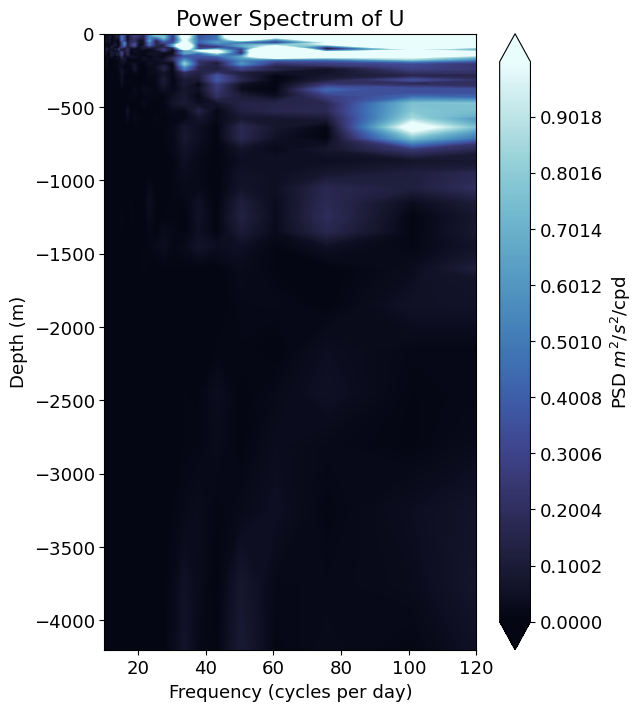

In [94]:
fig, ax = plt.subplots(figsize=(6,8))

psd_plot = np.where(psd > 1e-10, psd, np.nan)
levels = np.linspace(0,1.0,500)
cf = ax.contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax.set_title('Power Spectrum of U')
ax.set_xlabel('Frequency (cycles per day)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(-4200,0)
ax.set_xlim(10,120)

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('PSD $m^2/s^2$/cpd')
fig.savefig(foldername + 'U_spectrum_v_depth_linearcolor.png',dpi=300)

/tmp/ipykernel_684347/3349060151.py:5: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', norm=LogNorm(vmin=1e-4,vmax=1e0), cmap=cmo.ice)


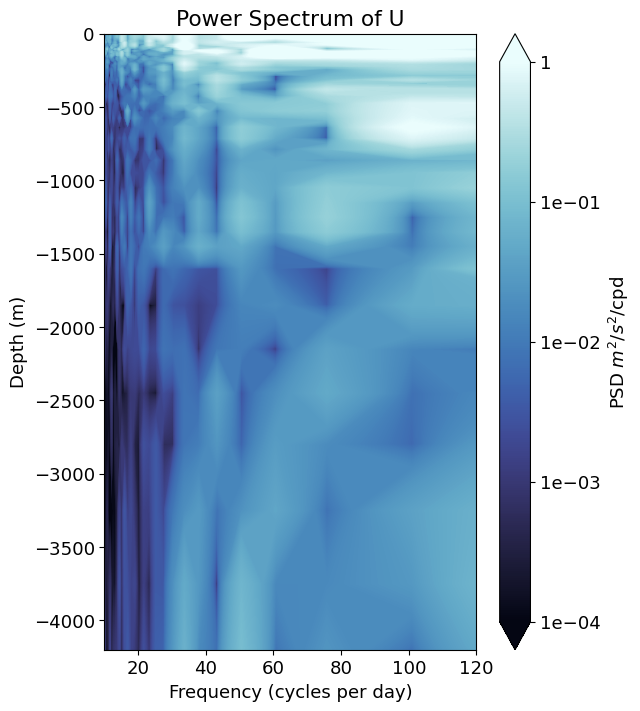

In [95]:
fig, ax = plt.subplots(figsize=(6,8))

psd_plot = np.where(psd > 1e-10, psd, np.nan)
levels = np.logspace(-4,0,500)
cf = ax.contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', norm=LogNorm(vmin=1e-4,vmax=1e0), cmap=cmo.ice)
ax.set_title('Power Spectrum of U')
ax.set_xlabel('Frequency (cycles per day)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(-4200,0)
ax.set_xlim(10,120)

cbar = fig.colorbar(cf, ax=ax)
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatter(base=10)
cbar.set_label('PSD $m^2/s^2$/cpd')
fig.savefig(foldername + 'U_spectrum_v_depth.png',dpi=300)

/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day


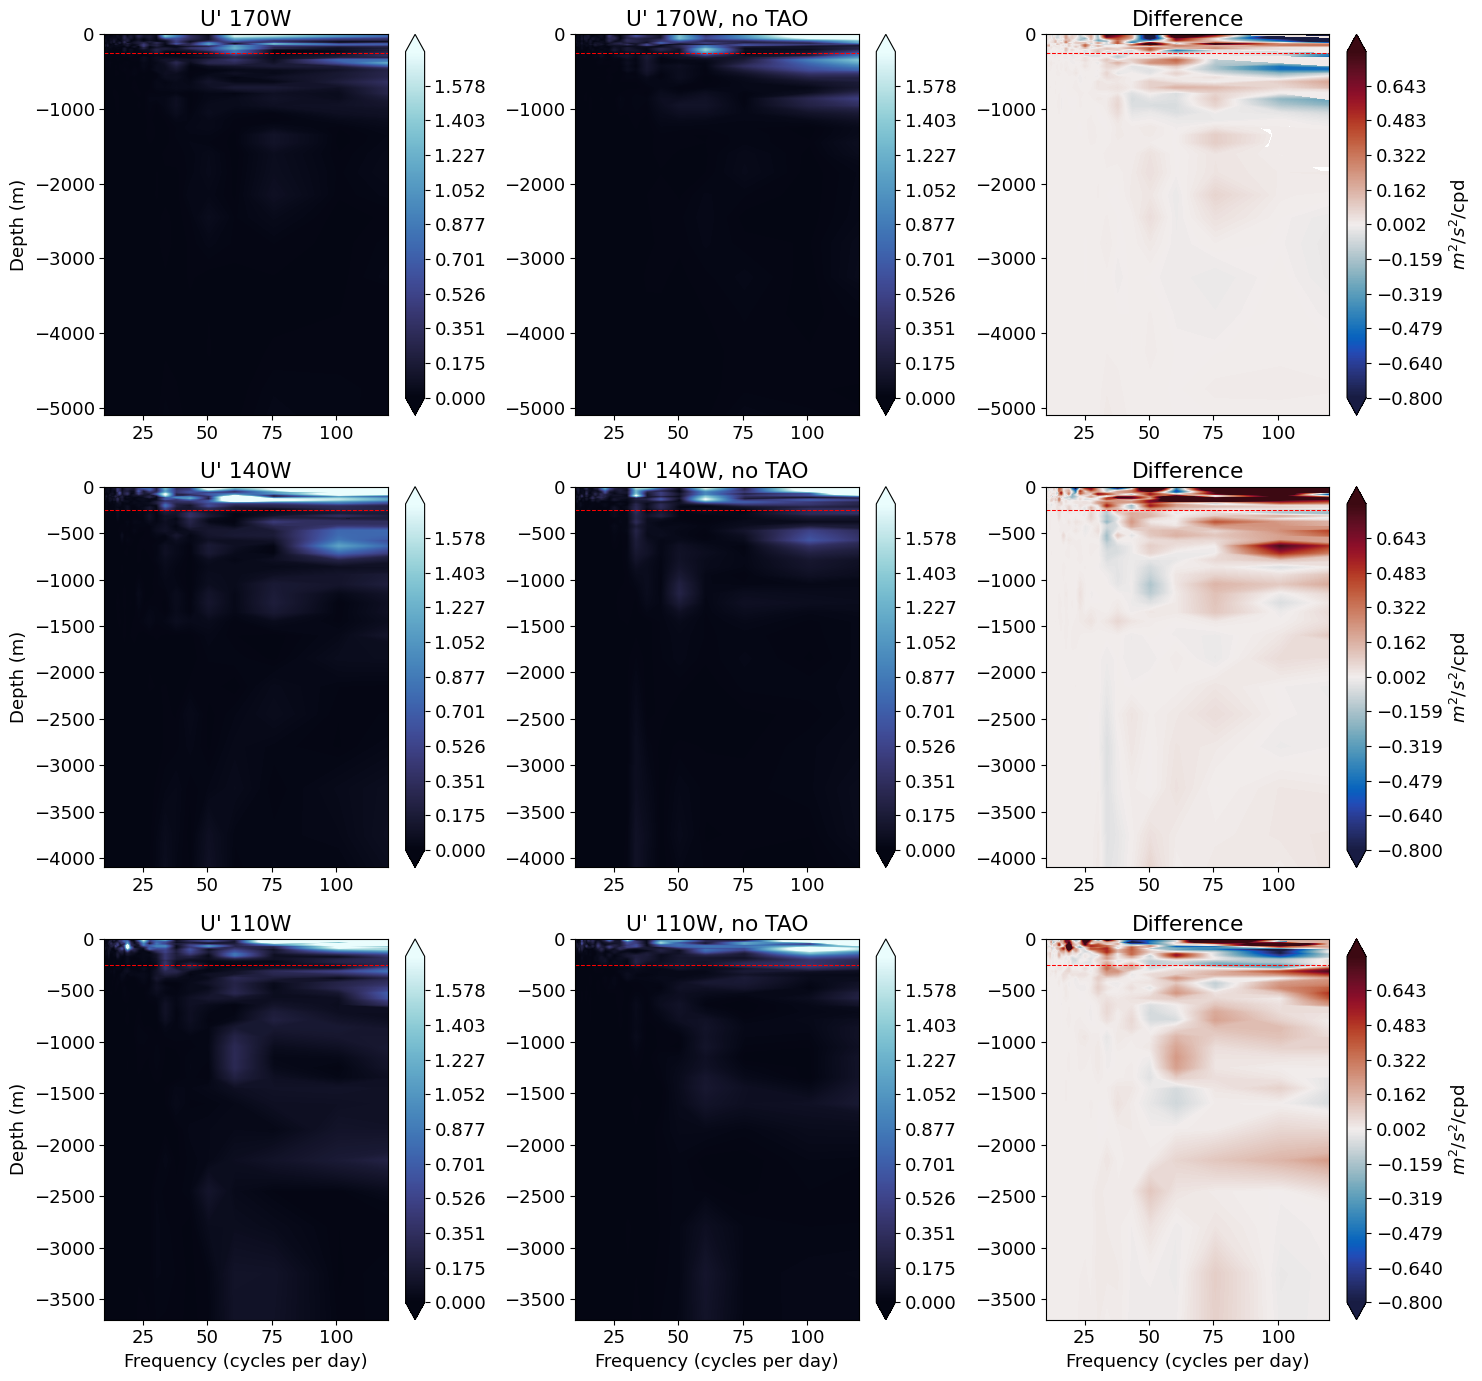

In [96]:
fig, ax = plt.subplots(figsize=(15,14),ncols=3,nrows=3)
levels = np.linspace(0,1.75,500)
uvel = UVEL.sel(YC=0.0, XC=190, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[0,0].contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,0].set_title('U\' 170W')
ax[0,0].set_xlabel('')
ax[0,0].set_ylabel('Depth (m)')
ax[0,0].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=190, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[0,1].contourf(freq_dpc, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,1].set_title('U\' 170W, no TAO')
ax[0,1].set_xlabel('')
ax[0,1].set_ylabel('')
ax[0,1].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,1])
cbar.set_label('')

levels = np.linspace(-0.8,0.8,500)
cf = ax[0,2].contourf(freq_dpc, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[0,2].set_title('Difference')
ax[0,2].set_xlabel('')
ax[0,2].set_ylabel('')
ax[0,2].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,1.75,500)
uvel = UVEL.sel(YC=0.0, XC=220, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[1,0].contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[1,0].set_title('U\' 140W')
ax[1,0].set_xlabel('')
ax[1,0].set_ylabel('Depth (m)')
ax[1,0].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=220, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[1,1].contourf(freq_dpc, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[1,1].set_title('U\' 140W, no TAO')
ax[1,1].set_xlabel('')
ax[1,1].set_ylabel('')
ax[1,1].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,1])
cbar.set_label('')

levels = np.linspace(-0.8,0.8,500)
cf = ax[1,2].contourf(freq_dpc, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[1,2].set_title('Difference')
ax[1,2].set_xlabel('')
ax[1,2].set_ylabel('')
ax[1,2].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,1.75,500)
uvel = UVEL.sel(YC=0.0, XC=250, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[2,0].contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,0].set_title('U\' 110W')
ax[2,0].set_xlabel('Frequency (cycles per day)')
ax[2,0].set_ylabel('Depth (m)')
ax[2,0].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=250, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[2,1].contourf(freq_dpc, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,1].set_title('U\' 110W, no TAO')
ax[2,1].set_xlabel('Frequency (cycles per day)')
ax[2,1].set_ylabel('')
ax[2,1].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,1])
cbar.set_label('')

levels = np.linspace(-0.8,0.8,500)
cf = ax[2,2].contourf(freq_dpc, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[2,2].set_title('Difference')
ax[2,2].set_xlabel('Frequency (cycles per day)')
ax[2,2].set_ylabel('')
ax[2,2].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,2])
cbar.set_label('$m^2/s^2$/cpd')

for ax in ax.flatten():
    ax.axhline(-250,color='r',ls='--',lw=0.75)
    ax.set_xlim(10,120)

plt.tight_layout()
fig.savefig(foldername + 'U_spectrum_v_depth_9Panel.png',dpi=300)

/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day


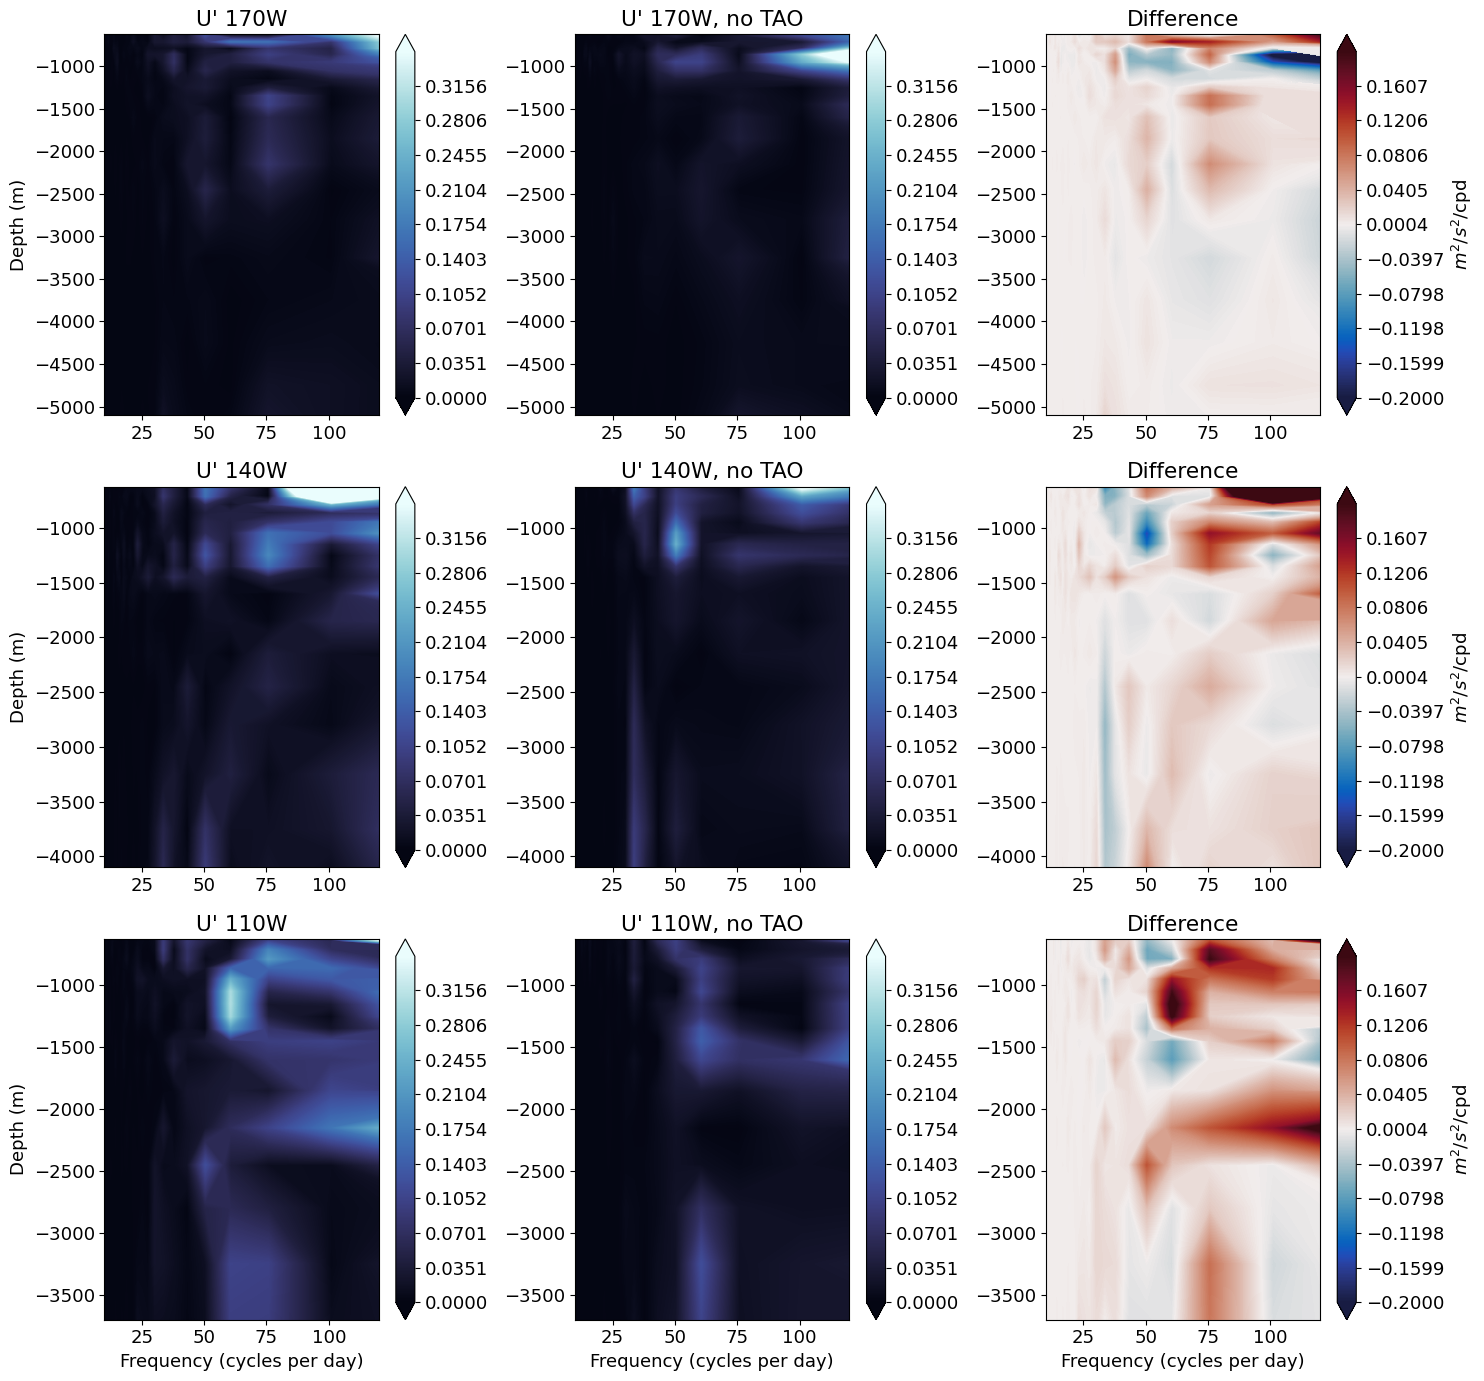

In [111]:
fig, ax = plt.subplots(figsize=(15,14),ncols=3,nrows=3)
levels = np.linspace(0,0.35,500)
uvel = UVEL.sel(YC=0.0, XC=190, method='nearest').sel(Z=slice(-600,-5500))
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[0,0].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(-600,-5500)), psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,0].set_title('U\' 170W')
ax[0,0].set_xlabel('')
ax[0,0].set_ylabel('Depth (m)')
ax[0,0].set_ylim(-5100,-625)
cbar = fig.colorbar(cf, ax=ax[0,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=190, method='nearest').sel(Z=slice(-600,-5500))
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[0,1].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(-600,-5500)), psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,1].set_title('U\' 170W, no TAO')
ax[0,1].set_xlabel('')
ax[0,1].set_ylabel('')
ax[0,1].set_ylim(-5100,-625)
cbar = fig.colorbar(cf, ax=ax[0,1])
cbar.set_label('')

levels = np.linspace(-0.2,0.2,500)
cf = ax[0,2].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(-600,-5500)), (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[0,2].set_title('Difference')
ax[0,2].set_xlabel('')
ax[0,2].set_ylabel('')
ax[0,2].set_ylim(-5100,-625)
cbar = fig.colorbar(cf, ax=ax[0,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,0.35,500)
uvel = UVEL.sel(YC=0.0, XC=220, method='nearest').sel(Z=slice(-600,-5500))
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[1,0].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(-600,-5500)), psd.T, levels=levels,extend='both', cmap=cmo.ice)
ax[1,0].set_title('U\' 140W')
ax[1,0].set_xlabel('')
ax[1,0].set_ylabel('Depth (m)')
ax[1,0].set_ylim(-4100,-625)
cbar = fig.colorbar(cf, ax=ax[1,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=220, method='nearest').sel(Z=slice(-600,-5500))
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[1,1].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(-600,-5500)), psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[1,1].set_title('U\' 140W, no TAO')
ax[1,1].set_xlabel('')
ax[1,1].set_ylabel('')
ax[1,1].set_ylim(-4100,-625)
cbar = fig.colorbar(cf, ax=ax[1,1])
cbar.set_label('')

levels = np.linspace(-0.2,0.2,500)
cf = ax[1,2].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(-600,-5500)), (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[1,2].set_title('Difference')
ax[1,2].set_xlabel('')
ax[1,2].set_ylabel('')
ax[1,2].set_ylim(-4100,-625)
cbar = fig.colorbar(cf, ax=ax[1,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,0.35,500)
uvel = UVEL.sel(YC=0.0, XC=250, method='nearest').sel(Z=slice(-600,-5500))
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[2,0].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(-600,-5500)), psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,0].set_title('U\' 110W')
ax[2,0].set_xlabel('Frequency (cycles per day)')
ax[2,0].set_ylabel('Depth (m)')
ax[2,0].set_ylim(-3700,-625)
cbar = fig.colorbar(cf, ax=ax[2,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=250, method='nearest').sel(Z=slice(-600,-5500))
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[2,1].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(-600,-5500)), psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,1].set_title('U\' 110W, no TAO')
ax[2,1].set_xlabel('Frequency (cycles per day)')
ax[2,1].set_ylabel('')
ax[2,1].set_ylim(-3700,-625)
cbar = fig.colorbar(cf, ax=ax[2,1])
cbar.set_label('')

levels = np.linspace(-0.2,0.2,500)
cf = ax[2,2].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(-600,-5500)), (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[2,2].set_title('Difference')
ax[2,2].set_xlabel('Frequency (cycles per day)')
ax[2,2].set_ylabel('')
ax[2,2].set_ylim(-3700,-625)
cbar = fig.colorbar(cf, ax=ax[2,2])
cbar.set_label('$m^2/s^2$/cpd')

for ax in ax.flatten():
    ax.axhline(-250,color='r',ls='--',lw=0.75)
    ax.set_xlim(10,120)

plt.tight_layout()
fig.savefig(foldername + 'U_spectrum_v_depth_9Panel_deep.png',dpi=300)

In [97]:
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import SymmetricalLogLocator

/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day


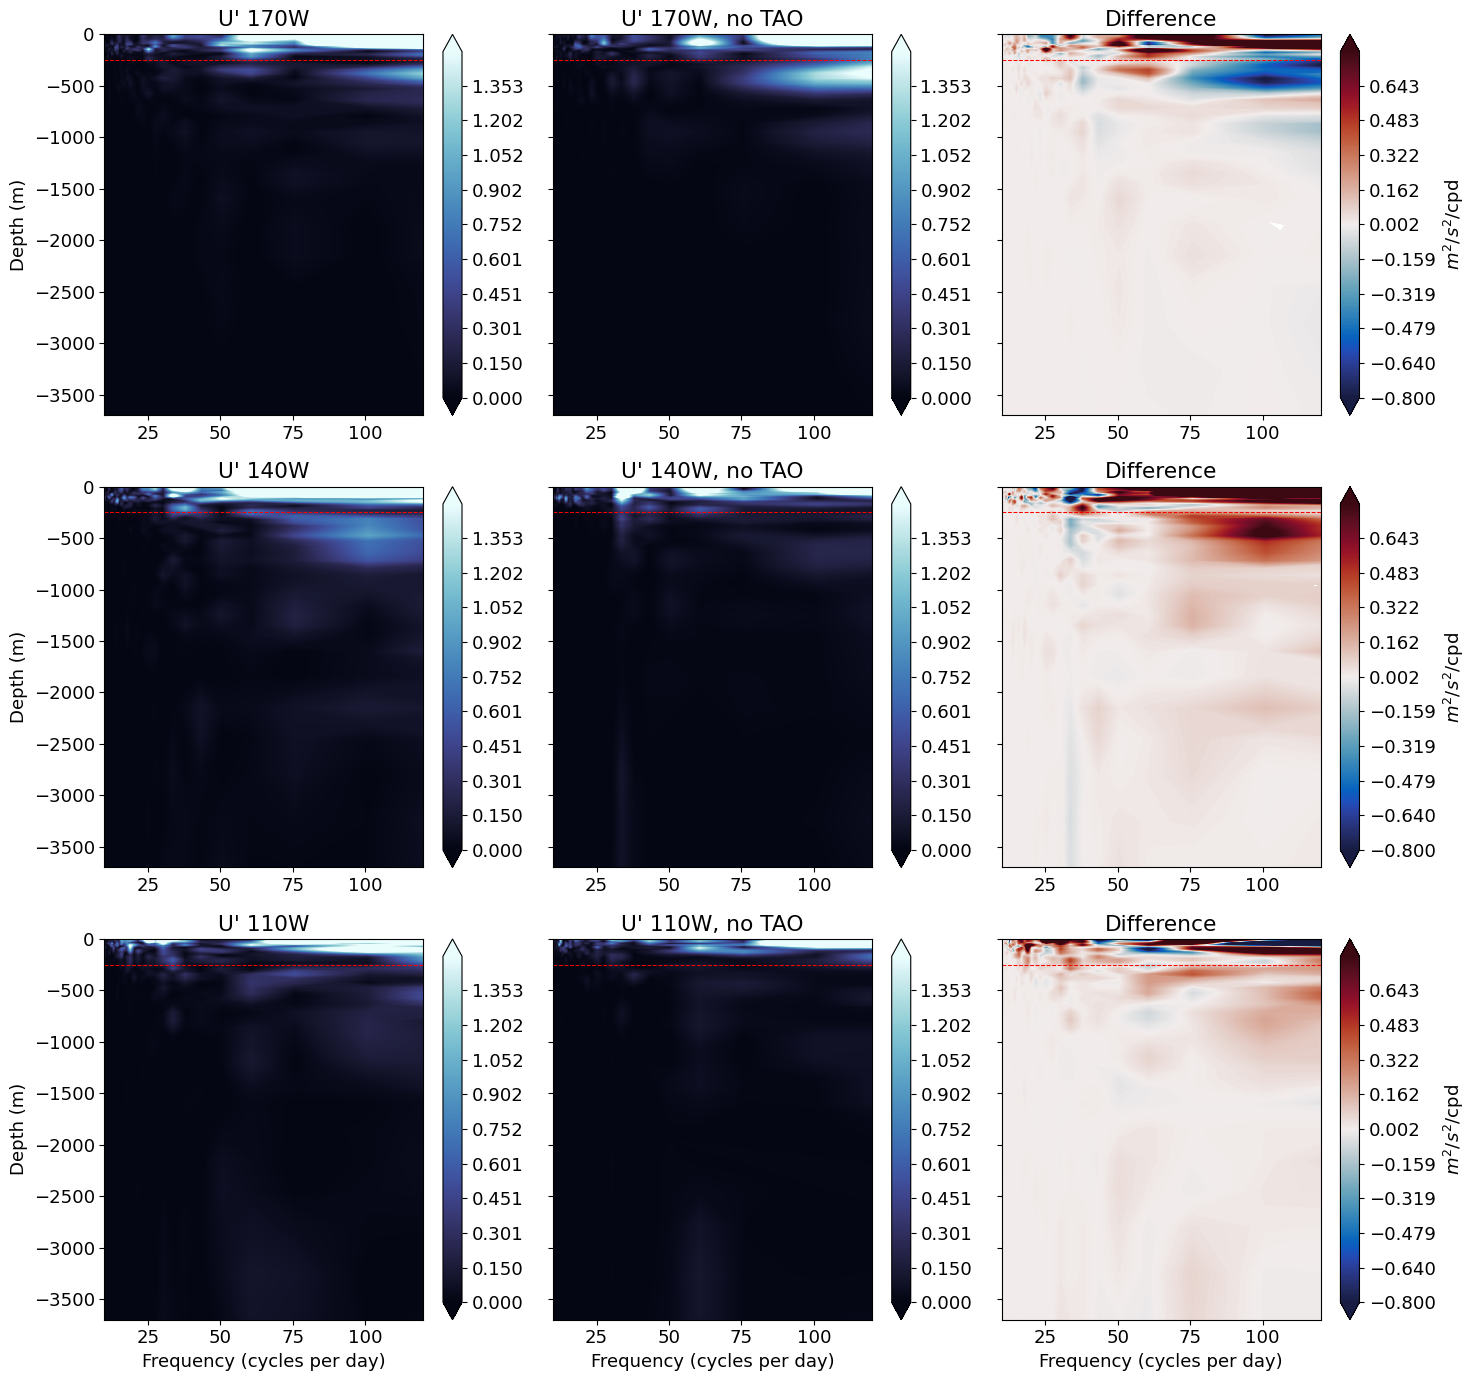

In [98]:
fig, ax = plt.subplots(figsize=(15,14),ncols=3,nrows=3,sharey=True)
levels = np.linspace(0,1.5,500)
uvel = UVEL.sel(YC=1.0, XC=190, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[0,0].contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,0].set_title('U\' 170W')
ax[0,0].set_xlabel('')
ax[0,0].set_ylabel('Depth (m)')
ax[0,0].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=1.0, XC=190, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[0,1].contourf(freq_dpc, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,1].set_title('U\' 170W, no TAO')
ax[0,1].set_xlabel('')
ax[0,1].set_ylabel('')
ax[0,1].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,1])
cbar.set_label('')

levels = np.linspace(-0.8,0.8,500)
cf = ax[0,2].contourf(freq_dpc, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[0,2].set_title('Difference')
ax[0,2].set_xlabel('')
ax[0,2].set_ylabel('')
ax[0,2].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,1.5,500)
uvel = UVEL.sel(YC=1.0, XC=220, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[1,0].contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[1,0].set_title('U\' 140W')
ax[1,0].set_xlabel('')
ax[1,0].set_ylabel('Depth (m)')
ax[1,0].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=1.0, XC=220, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[1,1].contourf(freq_dpc, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[1,1].set_title('U\' 140W, no TAO')
ax[1,1].set_xlabel('')
ax[1,1].set_ylabel('')
ax[1,1].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,1])
cbar.set_label('')

levels = np.linspace(-0.8,0.8,500)
cf = ax[1,2].contourf(freq_dpc, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[1,2].set_title('Difference')
ax[1,2].set_xlabel('')
ax[1,2].set_ylabel('')
ax[1,2].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,1.5,500)
uvel = UVEL.sel(YC=1.0, XC=250, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[2,0].contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,0].set_title('U\' 110W')
ax[2,0].set_xlabel('Frequency (cycles per day)')
ax[2,0].set_ylabel('Depth (m)')
ax[2,0].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=1.0, XC=250, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[2,1].contourf(freq_dpc, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,1].set_title('U\' 110W, no TAO')
ax[2,1].set_xlabel('Frequency (cycles per day)')
ax[2,1].set_ylabel('')
ax[2,1].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,1])
cbar.set_label('')

levels = np.linspace(-0.8,0.8,500)
cf = ax[2,2].contourf(freq_dpc, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[2,2].set_title('Difference')
ax[2,2].set_xlabel('Frequency (cycles per day)')
ax[2,2].set_ylabel('')
ax[2,2].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,2])
cbar.set_label('$m^2/s^2$/cpd')

for ax in ax.flatten():
    ax.axhline(-250,color='r',ls='--',lw=0.75)
    ax.set_xlim(10,120)

plt.tight_layout()
fig.savefig(foldername + 'U_spectrum_v_depth_9Panel_1N.png',dpi=300)

In [ ]:
lat = 0
uvel = UVEL.sel(YC=lat, XC=190, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
uvel = UVEL_noTAO.sel(YC=lat, XC=190, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)

integrated_psd = np.trapezoid(psd, x=freq_dpc, axis=0)
integrated_psd_noTAO = np.trapezoid(psd_noTAO, x=freq_dpc, axis=0)

fig, ax = plt.subplots(figsize=(5,8))
ax.plot(integrated_psd, ds_tpose_TAO.Z, color='tab:blue', lw=1.5, label='170W With TAO')
ax.plot(integrated_psd_noTAO, ds_tpose_TAO.Z, color='tab:blue', ls='--', lw=1.5,  label='170W No TAO')

uvel = UVEL.sel(YC=lat, XC=220, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
uvel = UVEL_noTAO.sel(YC=lat, XC=220, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)

integrated_psd = np.trapezoid(psd, x=freq_dpc, axis=0)
integrated_psd_noTAO = np.trapezoid(psd_noTAO, x=freq_dpc, axis=0)

ax.plot(integrated_psd, ds_tpose_TAO.Z, color='tab:orange', lw=1.5, label='140W With TAO')
ax.plot(integrated_psd_noTAO, ds_tpose_TAO.Z, color='tab:orange', ls='--', lw=1.5,  label='140W No TAO')

uvel = UVEL.sel(YC=lat, XC=250, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
uvel = UVEL_noTAO.sel(YC=lat, XC=250, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)

integrated_psd = np.trapezoid(psd, x=freq_dpc, axis=0)
integrated_psd_noTAO = np.trapezoid(psd_noTAO, x=freq_dpc, axis=0)

ax.plot(integrated_psd, ds_tpose_TAO.Z, color='tab:green', lw=1.5, label='110W With TAO')
ax.plot(integrated_psd_noTAO, ds_tpose_TAO.Z, color='tab:green', ls='--', lw=1.5,  label='110W No TAO')

ax.set_xlabel('$m^2/s^2$')
ax.set_ylabel('Depth (m)')
ax.set_title('Integrated Power Spectrum of U\'')
ax.semilogx()
ax.legend()
ax.set_ylim(-5500,0)

plt.tight_layout()
fig.savefig(foldername + 'U_PSD_integrated.png',dpi=300)

In [ ]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(12,8), ncols=3)
lats = [-1.5, 0, 1.5]
lons = [190, 220, 250]
strs = ['170', '140', '110']
depth_lim = [-5500, -4700, -3800]

# Define 3 visually even shades for each longitude (light → dark)
colors_dict = {
    190: ['#5b7bd5', '#2f4fa3', '#162c6b'],   # blue (light→dark but all fairly dark)
    220: ['#4aa96c', '#2e7d4f', '#184d30'],   # green
    250: ['#d14949', '#a52a2a', '#6b1515']    # red
}

# Loop over longitudes and axes
for lon, ax_sub, lon_str in zip(lons, ax.flatten(),strs):
    # Create shades for the latitudes
    color_shades = colors_dict[lon]  # get the 3 shades for this longitude
    
    for lat, color in zip(lats, color_shades):
        # With TAO
        uvel = UVEL.sel(YC=lat, XC=lon, method='nearest')
        _, _, psd, _, freq_dpc = psd_for_plot(uvel)
        
        # No TAO
        uvel_no = UVEL_noTAO.sel(YC=lat, XC=lon, method='nearest')
        _, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel_no)
        
        integrated_psd = np.trapezoid(psd, x=freq_dpc, axis=0)
        integrated_psd_noTAO = np.trapezoid(psd_noTAO, x=freq_dpc, axis=0)
        
        # Plot lines with shades
        ax_sub.plot(integrated_psd, ds_tpose_TAO.Z, color=color, lw=1.5, label=f'{lat}° With TAO')
        ax_sub.plot(integrated_psd_noTAO, ds_tpose_TAO.Z, color=color, lw=1.5, ls='--', label=f'{lat}° No TAO')
    
    ax_sub.set_title(f'{lon_str}°W')
    ax_sub.set_xlabel('$m^2/s^2$')
    ax_sub.semilogx()
    ax_sub.legend()
    ax_sub.set_ylim(depth_lim[lons.index(lon)], 0)

ax[0].set_ylabel('Depth (m)')

plt.tight_layout()
fig.savefig(foldername + 'U_PSD_integrated_3panel.png',dpi=300)

/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day


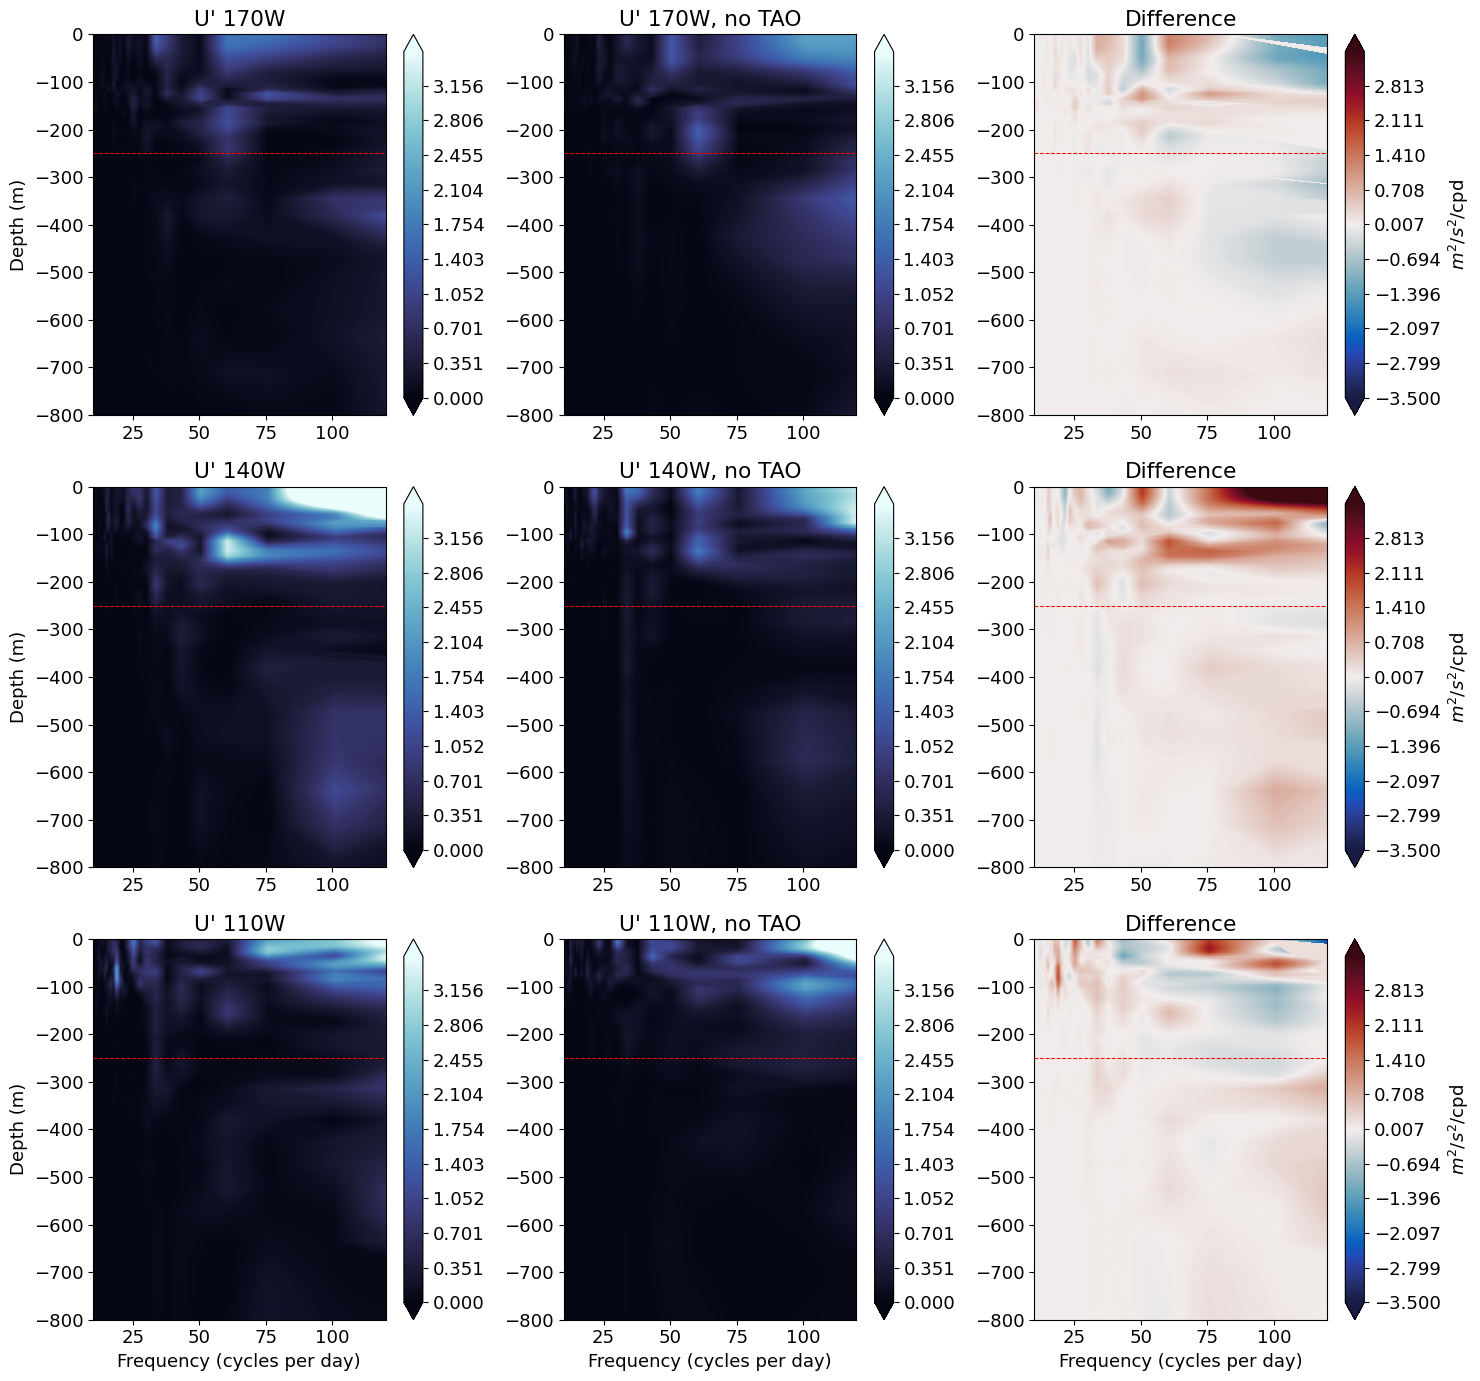

In [99]:
fig, ax = plt.subplots(figsize=(15,14),ncols=3,nrows=3)
levels = np.linspace(0,3.5,500)
uvel = UVEL.sel(YC=0.0, XC=190, method='nearest').sel(Z=slice(0,-900))
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[0,0].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,0].set_title('U\' 170W')
ax[0,0].set_xlabel('')
ax[0,0].set_ylabel('Depth (m)')
cbar = fig.colorbar(cf, ax=ax[0,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=190, method='nearest').sel(Z=slice(0,-900))
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[0,1].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,1].set_title('U\' 170W, no TAO')
ax[0,1].set_xlabel('')
ax[0,1].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[0,1])
cbar.set_label('')

levels = np.linspace(-3.5,3.5,500)
cf = ax[0,2].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[0,2].set_title('Difference')
ax[0,2].set_xlabel('')
ax[0,2].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[0,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,3.5,500)
uvel = UVEL.sel(YC=0.0, XC=220, method='nearest').sel(Z=slice(0,-900))
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[1,0].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[1,0].set_title('U\' 140W')
ax[1,0].set_xlabel('')
ax[1,0].set_ylabel('Depth (m)')
cbar = fig.colorbar(cf, ax=ax[1,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=220, method='nearest').sel(Z=slice(0,-900))
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[1,1].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[1,1].set_title('U\' 140W, no TAO')
ax[1,1].set_xlabel('')
ax[1,1].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[1,1])
cbar.set_label('')

levels = np.linspace(-3.5,3.5,500)
cf = ax[1,2].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[1,2].set_title('Difference')
ax[1,2].set_xlabel('')
ax[1,2].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[1,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,3.5,500)
uvel = UVEL.sel(YC=0.0, XC=250, method='nearest').sel(Z=slice(0,-900))
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[2,0].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,0].set_title('U\' 110W')
ax[2,0].set_xlabel('Frequency (cycles per day)')
ax[2,0].set_ylabel('Depth (m)')
cbar = fig.colorbar(cf, ax=ax[2,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=250, method='nearest').sel(Z=slice(0,-900))
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[2,1].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,1].set_title('U\' 110W, no TAO')
ax[2,1].set_xlabel('Frequency (cycles per day)')
ax[2,1].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[2,1])
cbar.set_label('')

levels = np.linspace(-3.5,3.5,500)
cf = ax[2,2].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[2,2].set_title('Difference')
ax[2,2].set_xlabel('Frequency (cycles per day)')
ax[2,2].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[2,2])
cbar.set_label('$m^2/s^2$/cpd')

for ax in ax.flatten():
    ax.axhline(-250,color='r',ls='--',lw=0.75)
    ax.set_xlim(10,120)
    ax.set_ylim(-800,0)

plt.tight_layout()
fig.savefig(foldername + 'U_spectrum_v_depth_9Panel_800m.png',dpi=300)

/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day


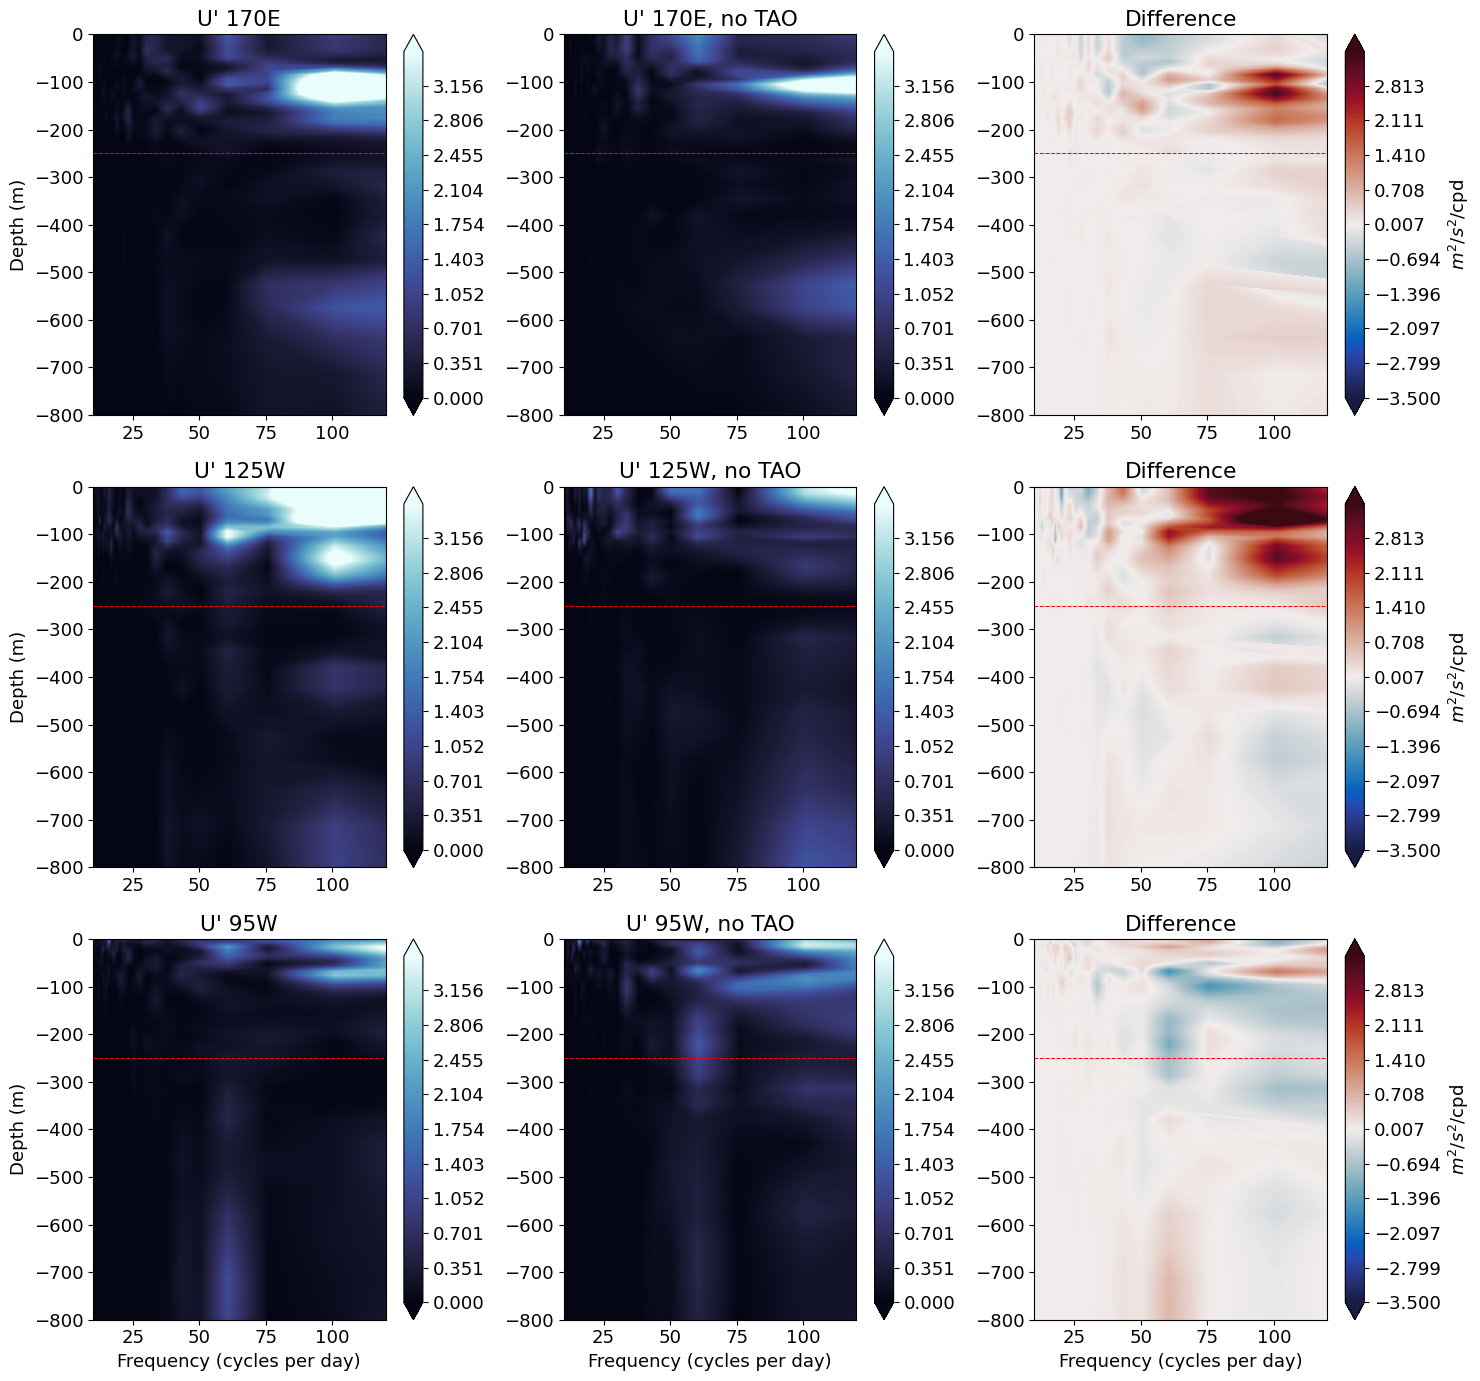

In [100]:
fig, ax = plt.subplots(figsize=(15,14),ncols=3,nrows=3)
levels = np.linspace(0,3.5,500)
uvel = UVEL.sel(YC=0.0, XC=170, method='nearest').sel(Z=slice(0,-900))
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[0,0].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,0].set_title('U\' 170E')
ax[0,0].set_xlabel('')
ax[0,0].set_ylabel('Depth (m)')
cbar = fig.colorbar(cf, ax=ax[0,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=170, method='nearest').sel(Z=slice(0,-900))
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[0,1].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,1].set_title('U\' 170E, no TAO')
ax[0,1].set_xlabel('')
ax[0,1].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[0,1])
cbar.set_label('')

levels = np.linspace(-3.5,3.5,500)
cf = ax[0,2].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[0,2].set_title('Difference')
ax[0,2].set_xlabel('')
ax[0,2].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[0,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,3.5,500)
uvel = UVEL.sel(YC=0.0, XC=235, method='nearest').sel(Z=slice(0,-900))
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[1,0].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[1,0].set_title('U\' 125W')
ax[1,0].set_xlabel('')
ax[1,0].set_ylabel('Depth (m)')
cbar = fig.colorbar(cf, ax=ax[1,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=235, method='nearest').sel(Z=slice(0,-900))
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[1,1].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[1,1].set_title('U\' 125W, no TAO')
ax[1,1].set_xlabel('')
ax[1,1].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[1,1])
cbar.set_label('')

levels = np.linspace(-3.5,3.5,500)
cf = ax[1,2].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[1,2].set_title('Difference')
ax[1,2].set_xlabel('')
ax[1,2].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[1,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,3.5,500)
uvel = UVEL.sel(YC=0.0, XC=265, method='nearest').sel(Z=slice(0,-900))
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[2,0].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,0].set_title('U\' 95W')
ax[2,0].set_xlabel('Frequency (cycles per day)')
ax[2,0].set_ylabel('Depth (m)')
cbar = fig.colorbar(cf, ax=ax[2,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=265, method='nearest').sel(Z=slice(0,-900))
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[2,1].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,1].set_title('U\' 95W, no TAO')
ax[2,1].set_xlabel('Frequency (cycles per day)')
ax[2,1].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[2,1])
cbar.set_label('')

levels = np.linspace(-3.5,3.5,500)
cf = ax[2,2].contourf(freq_dpc, ds_tpose_TAO.Z.sel(Z=slice(0,-900)), (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[2,2].set_title('Difference')
ax[2,2].set_xlabel('Frequency (cycles per day)')
ax[2,2].set_ylabel('')
cbar = fig.colorbar(cf, ax=ax[2,2])
cbar.set_label('$m^2/s^2$/cpd')

for ax in ax.flatten():
    ax.axhline(-250,color='r',ls='--',lw=0.75)
    ax.set_xlim(10,120)
    ax.set_ylim(-800,0)

plt.tight_layout()
fig.savefig(foldername + 'U_spectrum_v_depth_9Panel_800m_altLon.png',dpi=300)

/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_684347/3915652901.py:13: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day


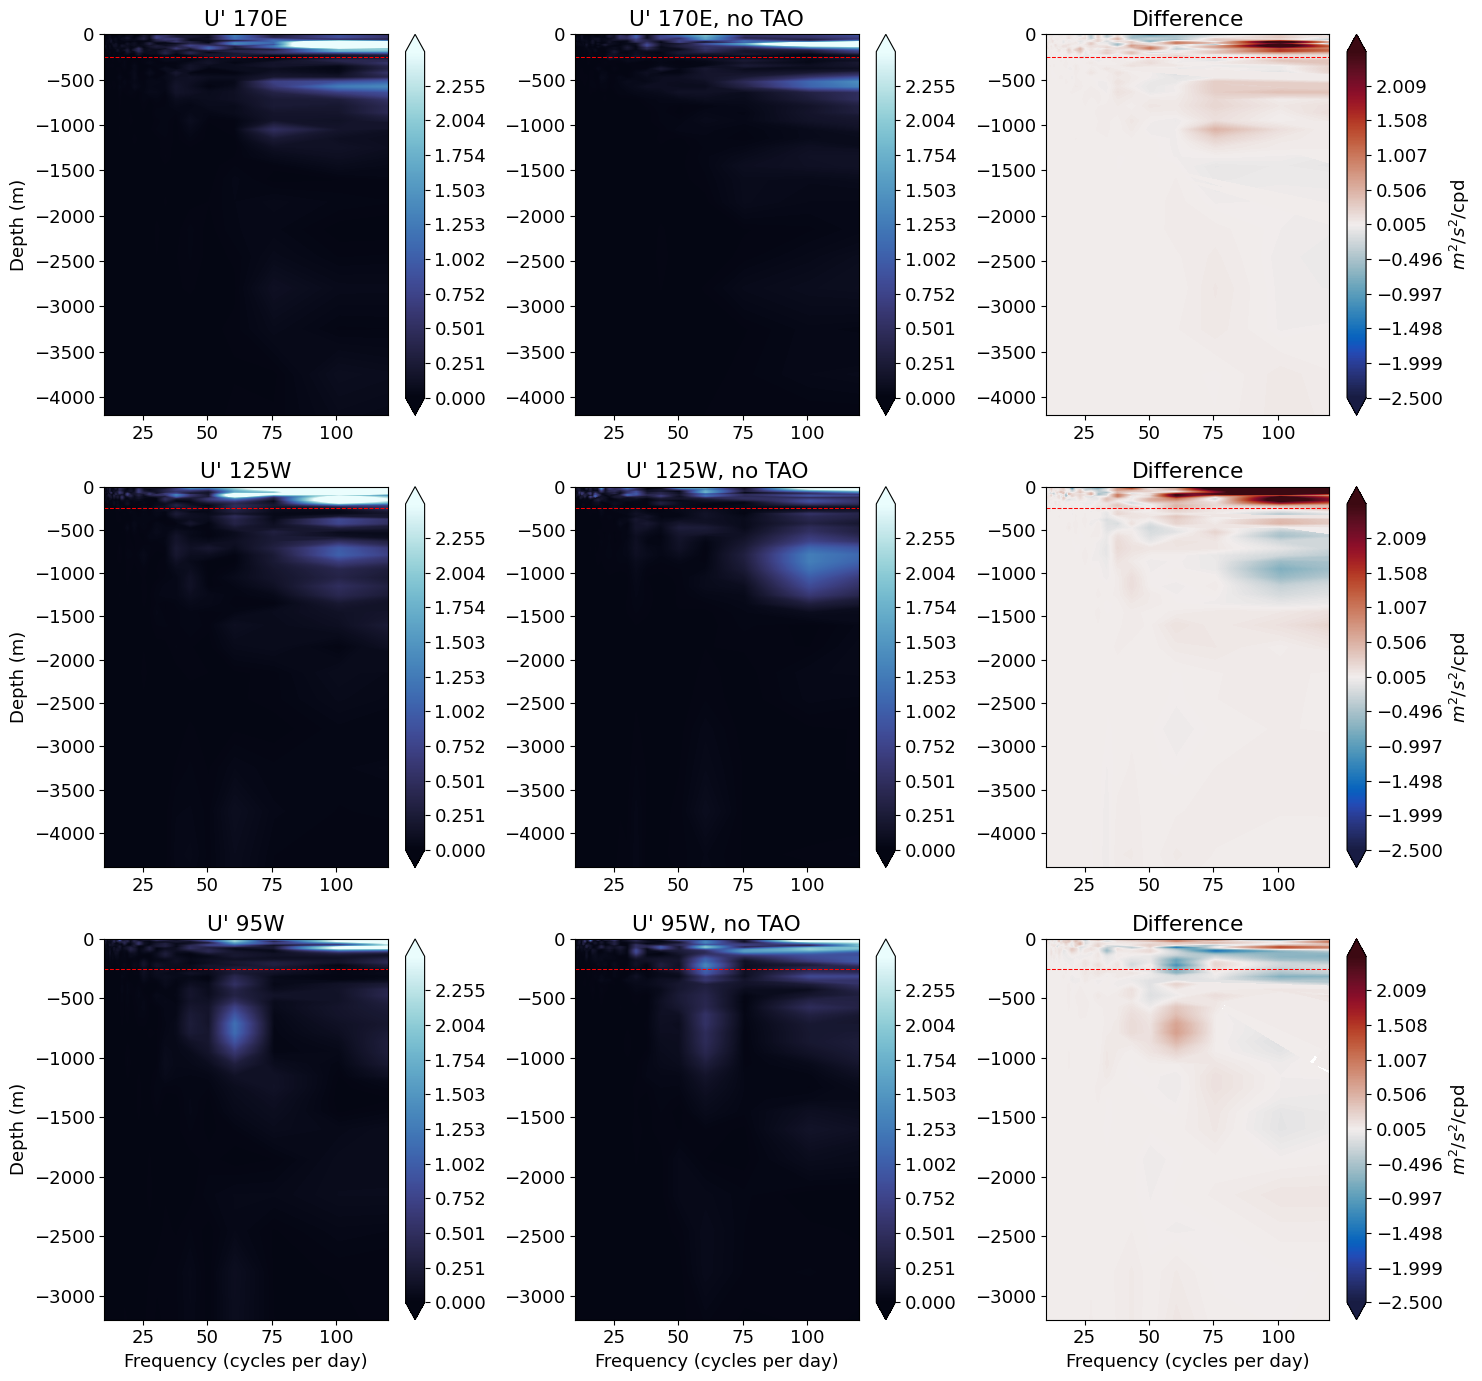

In [101]:
fig, ax = plt.subplots(figsize=(15,14),ncols=3,nrows=3)
levels = np.linspace(0,2.5,500)
uvel = UVEL.sel(YC=0.0, XC=170, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[0,0].contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,0].set_title('U\' 170E')
ax[0,0].set_xlabel('')
ax[0,0].set_ylabel('Depth (m)')
ax[0,0].set_ylim(-4200,0)
cbar = fig.colorbar(cf, ax=ax[0,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=170, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[0,1].contourf(freq_dpc, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[0,1].set_title('U\' 170E, no TAO')
ax[0,1].set_xlabel('')
ax[0,1].set_ylabel('')
ax[0,1].set_ylim(-4200,0)
cbar = fig.colorbar(cf, ax=ax[0,1])
cbar.set_label('')

levels = np.linspace(-2.5,2.5,500)
cf = ax[0,2].contourf(freq_dpc, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[0,2].set_title('Difference')
ax[0,2].set_xlabel('')
ax[0,2].set_ylabel('')
ax[0,2].set_ylim(-4200,0)
cbar = fig.colorbar(cf, ax=ax[0,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,2.5,500)
uvel = UVEL.sel(YC=0.0, XC=235, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[1,0].contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[1,0].set_title('U\' 125W')
ax[1,0].set_xlabel('')
ax[1,0].set_ylabel('Depth (m)')
ax[1,0].set_ylim(-4400,0)
cbar = fig.colorbar(cf, ax=ax[1,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=235, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[1,1].contourf(freq_dpc, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[1,1].set_title('U\' 125W, no TAO')
ax[1,1].set_xlabel('')
ax[1,1].set_ylabel('')
ax[1,1].set_ylim(-4400,0)
cbar = fig.colorbar(cf, ax=ax[1,1])
cbar.set_label('')

levels = np.linspace(-2.5,2.5,500)
cf = ax[1,2].contourf(freq_dpc, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[1,2].set_title('Difference')
ax[1,2].set_xlabel('')
ax[1,2].set_ylabel('')
ax[1,2].set_ylim(-4400,0)
cbar = fig.colorbar(cf, ax=ax[1,2])
cbar.set_label('$m^2/s^2$/cpd')

levels = np.linspace(0,2.5,500)
uvel = UVEL.sel(YC=0.0, XC=265, method='nearest')
_, _, psd, _, freq_dpc = psd_for_plot(uvel)
# psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[2,0].contourf(freq_dpc, ds_tpose_TAO.Z, psd.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,0].set_title('U\' 95W')
ax[2,0].set_xlabel('Frequency (cycles per day)')
ax[2,0].set_ylabel('Depth (m)')
ax[2,0].set_ylim(-3200,0)
cbar = fig.colorbar(cf, ax=ax[2,0])
cbar.set_label('')

uvel = UVEL_noTAO.sel(YC=0.0, XC=265, method='nearest')
_, _, psd_noTAO, _, freq_dpc = psd_for_plot(uvel)
# psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[2,1].contourf(freq_dpc, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, extend='both', cmap=cmo.ice)
ax[2,1].set_title('U\' 95W, no TAO')
ax[2,1].set_xlabel('Frequency (cycles per day)')
ax[2,1].set_ylabel('')
ax[2,1].set_ylim(-3200,0)
cbar = fig.colorbar(cf, ax=ax[2,1])
cbar.set_label('')

levels = np.linspace(-2.5,2.5,500)
cf = ax[2,2].contourf(freq_dpc, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, extend='both', cmap=cmo.balance)
ax[2,2].set_title('Difference')
ax[2,2].set_xlabel('Frequency (cycles per day)')
ax[2,2].set_ylabel('')
ax[2,2].set_ylim(-3200,0)
cbar = fig.colorbar(cf, ax=ax[2,2])
cbar.set_label('$m^2/s^2$/cpd')

for ax in ax.flatten():
    ax.axhline(-250,color='r',ls='--',lw=0.75)
    ax.set_xlim(10,120)

plt.tight_layout()
fig.savefig(foldername + 'U_spectrum_v_depth_9Panel_altLon.png',dpi=300)

In [102]:
client.shutdown()
cluster.close()
client.close()